<a href="https://colab.research.google.com/github/Mariano-ds/centollas2026/blob/main/mariano/mariano_tp2.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **Diplomatura en Ciencia de Datos, Aprendizaje Automático y sus Aplicaciones**

## **Edición 2026**

### Parte 2: Análisis exploratorio y curación de datos

---
## Mentoría 15: *¿Cuándo y dónde pescar Centollas en el Canal Beagle?*

**Objetivo**: responder al menos tres de las preguntas planteadas por el grupo en el trabajo práctico 1.

Se espera un manejo más avanzado del set de datos, en donde el grupo de trabajo relacione las distintas columnas del dataset (variables) para responder preguntas con una complejidad mayor que la de realizar una mera descripción.

Cada respuesta a cada pregunta debe contener los siguientes apartados para considerarse completa:

1. **Planteo de la pregunta.** Se deben incluir las implicancias o las consecuencias de poder responderla. Por ejemplo, si la pregunta es ¿cuándo presentan mayor cantidad de huevos las hembras de cada una de las especies? Tiene implicancia directa en el manejo pesquero de la especie. Explicitar.

2. **Desarrollo del paso a paso que se hizo para responder a la pregunta.** Por ejemplo, ¿cómo se consideraron los datos faltantes? ¿qué individuos se consideraron y cuáles no?

3. Al menos **un gráfico por pregunta respondida**, así como su interpretación.

In [11]:
# Librerias utilizadas
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
import numpy as np
import pandas as pd
import seaborn as sns
import missingno as msno
import re

from google.colab import drive

sns.set_context('talk')
pd.options.display.max_rows = 99999
pd.options.display.max_colwidth = 400

In [12]:
# Importo dataset original
url_original_data = "https://raw.github.com/luciabergagna-jpg/centoll/main/centollas_mentoria.csv"
data_original = pd.read_csv(url_original_data, sep=';', engine='python', encoding='latin1')

In [13]:
# Cargo el CSV local guardado en Drive con datos jul97
url_jul97 = 'https://raw.github.com/Mariano-ds/centollas2026/main/datos/jul97.csv'
data_jul97 = pd.read_csv(url_jul97, sep=';', engine='python', encoding='utf-8-sig')

In [14]:
# Estandarizacion previa
data_original.columns = data_original.columns.str.strip().str.lower()
data_jul97.columns = data_jul97.columns.str.strip().str.lower()

# Concatenar los DataFrames
# axis=0 une por filas alineando automáticamente por nombre de columna
# ignore_index=True reindexa las filas de 0 a N para evitar índices repetidos
df_full = pd.concat([data_original, data_jul97], axis=0, ignore_index=True)

# Confirmación de la estructura unificada
print(f"Filas totales: {df_full.shape[0]} | Columnas totales: {df_full.shape[1]}")
df_raw = df_full.copy()
df_raw.head(2)

Filas totales: 13114 | Columnas totales: 20


,fecha,rk,tipo,localizacion,latitud,longitud,profundidad,especie,sexo,estado_caparazon,cirripedio,largo_caparazon,ancho_caparazon,largo_quela,ancho_quela,huevos,parasito,observaciones,unnamed: 18,unnamed: 19
0,ene_96,1,Captura total de 3 trampas,frente bal. Ponsatti,NaN,NaN,23.0,2,1,4.0,3,87.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,ene_96,2,Captura total de 3 trampas,frente bal. Ponsatti,NaN,NaN,23.0,2,2,3.0,2,77.1,NaN,NaN,NaN,1,NaN,NaN,NaN,NaN


In [15]:
df_raw.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 13114 entries, 0 to 13113
Data columns (total 20 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   fecha             13114 non-null  object 
 1   rk                13114 non-null  int64  
 2   tipo              13114 non-null  object 
 3   localizacion      9021 non-null   object 
 4   latitud           7970 non-null   float64
 5   longitud          7970 non-null   float64
 6   profundidad       9765 non-null   float64
 7   especie           13114 non-null  int64  
 8   sexo              13114 non-null  int64  
 9   estado_caparazon  13106 non-null  float64
 10  cirripedio        1840 non-null   object 
 11  largo_caparazon   13087 non-null  float64
 12  ancho_caparazon   183 non-null    float64
 13  largo_quela       196 non-null    float64
 14  ancho_quela       198 non-null    float64
 15  huevos            3771 non-null   object 
 16  parasito          296 non-null    object

<Axes: >

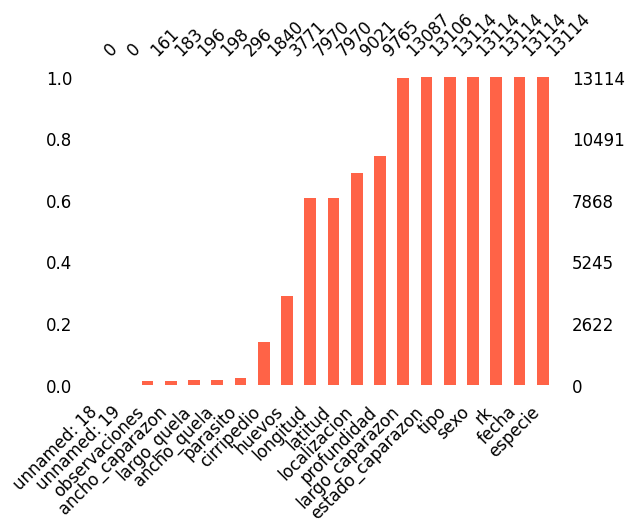

In [16]:
# Visualizacion de valores nulos
msno.bar(df_raw,figsize=(6, 4), sort="ascending",fontsize=12, color='tomato')

In [17]:
# Estudio porcentual de valores nulos
faltantes = df_raw.isnull().mean().sort_values(ascending=False) * 100
print(faltantes[faltantes > 0].round(2))

unnamed: 18         100.00
unnamed: 19         100.00
observaciones        98.77
ancho_caparazon      98.60
largo_quela          98.51
ancho_quela          98.49
parasito             97.74
cirripedio           85.97
huevos               71.24
latitud              39.23
longitud             39.23
localizacion         31.21
profundidad          25.54
largo_caparazon       0.21
estado_caparazon      0.06
dtype: float64


## 0. Limpieza inicial del dataset  

Se replican los pasos más elementales usados en la primera parte del proyecto.

In [18]:
# Se eliminan columnas vacías generadas por separadores sobrantes al final de cada fila
df_raw.drop(columns=['unnamed: 18', 'unnamed: 19'], inplace=True)
df_raw.dropna(subset=['estado_caparazon', 'largo_caparazon'],how='any',inplace=True)
print(f"Filas: {df_raw.shape[0]:,} | Columnas: {df_raw.shape[1]}")

Filas: 13,083 | Columnas: 18


Ahora tenemos una noción más detallada de qué valores contiene cada variable. Las columnas más relevantes para nuestro estudio serán las asociadas a la cantidad de cangrejos en la muestra, su ubicación temporal y espacial, seguido de las características físicas de los mismos.

Con la siguiente interpretación, procedemos a limpiar la columna de tipo de captura:

In [19]:
df_raw['tipo'].value_counts()

,count
tipo,
Captura total de 4 trampas,895
Captura total de 3 trampas,893
Captura total de 10 trampas,813
desembarque 1,779
desembarque 2,747
Captura total de 5 trampas,724
Captura total de 2 trampas,709
Captura total de 1 trampa,618
Captura total de 2.5 trampas,588


In [20]:
def extraer_num_trampas(tipo_str):
    """
    Extrae el número de trampas equivalentes desde el campo 'tipo'.
    - Si el texto contiene 'trampa' -> devuelve el número tal cual.
    - Si el texto contiene 'linea' o 'línea' -> devuelve el número * 10 (1 línea = 10 trampas).
    - Cualquier otro tipo (desembarque, muestreo de cubierta, wapisa, becasses, etc.) -> NaN.
    """
    if pd.isna(tipo_str):
        return np.nan

    texto = str(tipo_str).lower()

    match = re.search(r'(\d+\.?\d*)', texto)
    if not match:
        return np.nan

    numero = float(match.group(1))

    if 'trampa' in texto:
        return numero
    elif 'linea' in texto or 'línea' in texto:
        return numero * 10  # 1 linea = 10 trampas
    else:
        return np.nan  # los otros casos le mando un NaN

In [21]:
# Aplicar función
df_raw['num_trampas'] = df_raw['tipo'].apply(extraer_num_trampas)

n_total = len(df_raw)
n_validos = df_raw['num_trampas'].notna().sum()
n_excluidos = n_total - n_validos

print("=="*50)
print(f" Registros con esfuerzo de pesca identificable: {n_validos} ({n_validos/n_total*100:.1f}%)")
print(f" Registros excluidos del cálculo de IAR (índice de abundancia relativa): {n_excluidos} ({n_excluidos/n_total*100:.1f}%)")
print("=="*50)

print("\nCategorías excluidas (sin equivalente en trampas):")
print(df_raw[df_raw['num_trampas'].isna()]['tipo'].value_counts())

 Registros con esfuerzo de pesca identificable: 9678 (74.0%)
 Registros excluidos del cálculo de IAR (índice de abundancia relativa): 3405 (26.0%)

Categorías excluidas (sin equivalente en trampas):
tipo
desembarque 1              779
desembarque 2              747
desembarque 0              577
Muestreo de Desembarque    484
Muestreo de cubierta 1     369
Muestreo de cubierta 2     175
Muestreo de cubierta 0     131
Captura por la Wapisa       74
Muestreo de cubierta 3      55
lithodes de becasses        14
Name: count, dtype: int64


In [22]:
df_raw.columns

Index(['fecha', 'rk', 'tipo', 'localizacion', 'latitud', 'longitud',
       'profundidad', 'especie', 'sexo', 'estado_caparazon', 'cirripedio',
       'largo_caparazon', 'ancho_caparazon', 'largo_quela', 'ancho_quela',
       'huevos', 'parasito', 'observaciones', 'num_trampas'],
      dtype='object')

In [23]:
## Calculemos el indice de abundancia relativa (IAR)

df_trampas = df_raw[df_raw['num_trampas'].notna()].copy()
print(f"Registros originales: {len(df_raw)}")
print(f"Registros descartados (desembarque, muestreo de cubierta, etc.): {len(df_raw) - len(df_trampas)}")

# Agrupar por localización, fecha Y tipo -> cada combinación es un evento de muestreo independiente
iar_data = []
for (loc, fecha, tipo), group in df_trampas.groupby(['localizacion', 'fecha', 'tipo']):
    num_capturas = len(group)
    num_trampas_evento = group['num_trampas'].iloc[0]

    iar = num_capturas / num_trampas_evento if num_trampas_evento > 0 else 0

    iar_data.append({
        'Localización': loc,
        'Fecha': fecha,
        'Tipo': tipo,
        'N_Capturas': num_capturas,
        'N_Trampas': num_trampas_evento,
        'IAR': iar
    })

df_iar = pd.DataFrame(iar_data)
print("\n📊 Registros de IAR (por evento):")
print(df_iar.to_string(index=False))

iar_por_loc = df_iar.groupby('Localización').agg(
    N_Capturas=('N_Capturas', 'sum'),
    N_Trampas=('N_Trampas', 'sum')
).reset_index()
iar_por_loc['IAR_Total'] = iar_por_loc['N_Capturas'] / iar_por_loc['N_Trampas']
iar_por_loc = iar_por_loc.sort_values('IAR_Total', ascending=False)
iar_por_loc = iar_por_loc.set_index('Localización')

print(f"\n IAR calculado")
print(f"   Máximo IAR: {iar_por_loc['IAR_Total'].max():.4f} ({iar_por_loc['IAR_Total'].idxmax()})")
print(f"   Mínimo IAR: {iar_por_loc['IAR_Total'].min():.4f} ({iar_por_loc['IAR_Total'].idxmin()})")
print(f"   Promedio IAR: {iar_por_loc['IAR_Total'].mean():.4f}")

Registros originales: 13083
Registros descartados (desembarque, muestreo de cubierta, etc.): 3405

📊 Registros de IAR (por evento):
                                    Localización    Fecha                          Tipo  N_Capturas  N_Trampas        IAR
                            frente bal. Ponsatti   ene_96    Captura total de 3 trampas         235       3.00  78.333333
                                   E I. Martillo   jul_96  Captura total de 0.8 trampas         183       0.80 228.750000
                                   E I. Martillo   jul_96     Captura total de 1 trampa         169       1.00 169.000000
                                   E I. Martillo   jul_96  Captura total de 1.5 trampas         187       1.50 124.666667
                                        Martillo   jul_96     Captura total de 5 lineas           3      50.00   0.060000
                               Martillo y Yunque   jul_96     Captura total de 9 lineas          15      90.00   0.166667
N Snipe al tra

In [24]:
# 1. Definir la máscara para eventos con número de trampas válido
mask_trampas = df_raw['num_trampas'].notna() & (df_raw['num_trampas'] > 0)

# 2. Inicializar la columna IAR con NaN
df_raw['IAR'] = np.nan

# 3. Contar capturas (número de filas) por cada evento (localizacion, fecha, tipo)
capturas_por_evento = df_raw[mask_trampas].groupby(['localizacion', 'fecha', 'tipo'])['num_trampas'].transform('count')

# 4. Calcular el IAR vectorizado (Capturas / Trampas) para los registros válidos
df_raw.loc[mask_trampas, 'IAR'] = capturas_por_evento / df_raw.loc[mask_trampas, 'num_trampas']

In [25]:
import plotly.express as px

# Coordenadas promedio por localización
coords_por_loc = df_raw.dropna(subset=['latitud', 'longitud']).groupby('localizacion').agg(
    latitud=('latitud', 'mean'),
    longitud=('longitud', 'mean')
).reset_index()

# Unir con el IAR agregado
mapa_iar = coords_por_loc.merge(
    iar_por_loc.reset_index(),
    left_on='localizacion', right_on='Localización',
    how='inner'
)

fig_todos = px.scatter_map(
    mapa_iar,
    lat="latitud",
    lon="longitud",
    size="IAR_Total",
    color="IAR_Total",
    color_continuous_scale="YlOrRd",
    hover_name="localizacion",
    hover_data={"N_Capturas": True, "N_Trampas": True, "IAR_Total": ':.3f'},
    zoom=8,
    map_style="open-street-map",
    title="IAR en todas las localizaciones — picos de concentración visibles"
)
fig_todos.update_layout(
    mapbox_bounds={
        "west": mapa_iar.longitud.min(),
        "east": mapa_iar.longitud.max(),
        "south": mapa_iar.latitud.min(),
        "north": mapa_iar.latitud.max()
    }
)
fig_todos.show()

In [27]:
df_filtered = df_raw.copy()

# 1. Crear una bandera de auditoría para rastrear qué filas fueron imputadas
df_filtered['coord_imputadas'] = df_filtered['latitud'].isnull() | df_filtered['longitud'].isnull()

# 2. Imputar latitud y longitud con la media del grupo 'localizacion'
df_filtered['latitud'] = df_filtered['latitud'].fillna(
    df_filtered.groupby('localizacion')['latitud'].transform('median')
)

df_filtered['longitud'] = df_filtered['longitud'].fillna(
    df_filtered.groupby('localizacion')['longitud'].transform('median')
)

# 3. Reportar el resultado del proceso
recuperados = df_filtered['coord_imputadas'] & df_filtered['latitud'].notnull()
remoto_nulos = df_filtered['latitud'].isnull().sum()

print(f"Registros imputados con éxito: {recuperados.sum()}")
print(f"Registros sin datos de posición (sin referencias previas de localización): {remoto_nulos}")

Registros imputados con éxito: 25
Registros sin datos de posición (sin referencias previas de localización): 5113


In [28]:
# Cuantos nulos tiene la columna latitud
df_filtered['longitud'].isnull().sum()

np.int64(5113)

In [29]:
print(f"Filas: {df_filtered.shape[0]:,} | Columnas: {df_filtered.shape[1]}")
df_filtered.sample(5)

Filas: 13,083 | Columnas: 21


,fecha,rk,tipo,localizacion,latitud,longitud,profundidad,especie,sexo,estado_caparazon,...,largo_caparazon,ancho_caparazon,largo_quela,ancho_quela,huevos,parasito,observaciones,num_trampas,IAR,coord_imputadas
7849,oct_97,1868,Captura total de 1.75 trampas,wp 171,-54.921150,-67.110083,39.0,2,1,3.0,...,90.5,NaN,NaN,NaN,NaN,NaN,NaN,1.75,94.285714,False
12736,jul_97,1688,Captura total de 0.75 trampas,wp 159,-54.941483,-66.973950,33.0,2,1,3.0,...,79.9,NaN,NaN,NaN,NaN,NaN,NaN,0.75,184.000000,False
5985,oct_96,1415,Captura por la Wapisa,al O del Fronton Gable,NaN,NaN,30.0,1,1,2.0,...,108.8,114.0,70.3,34.9,NaN,NaN,NaN,NaN,NaN,True
3735,jul_96,1010,Captura total de 10 trampas,entre Yunque y Martillo,-54.899833,-67.358617,19.0,2,1,3.0,...,74.9,NaN,NaN,NaN,NaN,NaN,NaN,10.00,20.400000,False
11035,oct_98,2452,desembarque 2,NaN,NaN,NaN,45.0,2,1,4.0,...,89.6,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,True


In [30]:
# Estudio porcentual de valores nulos
new_faltantes = df_filtered.isnull().mean().sort_values(ascending=False) * 100
print(new_faltantes[new_faltantes > 0].round(2))

observaciones      98.91
ancho_caparazon    98.62
largo_quela        98.51
ancho_quela        98.51
parasito           97.75
cirripedio         85.94
huevos             71.29
latitud            39.08
longitud           39.08
IAR                32.25
localizacion       31.26
num_trampas        26.03
profundidad        25.58
dtype: float64


Ya tenemos corregida la variable que da cuenta de la cantidad de individuos muestreados en cada entrada. Ahora procesemos la variable temporal

In [31]:
df_filtered['fecha'].unique()

array(['ene_96', 'abril_96', 'jul_96', 'oct_96', 'oct_97', 'oct_98',
       'jul_97'], dtype=object)

In [32]:
#df_corrected = process_temporal_features(df_filtered, col='fecha')
df_corrected = df_filtered.copy()
df_corrected.head()

,fecha,rk,tipo,localizacion,latitud,longitud,profundidad,especie,sexo,estado_caparazon,...,largo_caparazon,ancho_caparazon,largo_quela,ancho_quela,huevos,parasito,observaciones,num_trampas,IAR,coord_imputadas
0,ene_96,1,Captura total de 3 trampas,frente bal. Ponsatti,NaN,NaN,23.0,2,1,4.0,...,87.0,NaN,NaN,NaN,NaN,NaN,NaN,3.0,78.333333,True
1,ene_96,2,Captura total de 3 trampas,frente bal. Ponsatti,NaN,NaN,23.0,2,2,3.0,...,77.1,NaN,NaN,NaN,1,NaN,NaN,3.0,78.333333,True
2,ene_96,3,Captura total de 3 trampas,frente bal. Ponsatti,NaN,NaN,23.0,2,2,3.0,...,74.6,NaN,NaN,NaN,1,NaN,NaN,3.0,78.333333,True
3,ene_96,4,Captura total de 3 trampas,frente bal. Ponsatti,NaN,NaN,23.0,2,1,3.0,...,75.6,NaN,NaN,NaN,NaN,NaN,NaN,3.0,78.333333,True
4,ene_96,5,Captura total de 3 trampas,frente bal. Ponsatti,NaN,NaN,23.0,2,2,3.0,...,75.6,NaN,NaN,NaN,1,NaN,NaN,3.0,78.333333,True


Ya tenemos corregida la fecha. Ahora corrijamos las variables de localizacion: Se eliminan las entradas con localizacion, latitud y altitud simultaneamente nulas

In [33]:
# Elimina la fila SOLO si latitud, longitud y localizacion son NaN simultáneamente
df_corrected = df_corrected.dropna(subset=['latitud', 'longitud', 'localizacion'], how='all').copy()
print(f"Filas: {df_corrected.shape[0]:,} | Columnas: {df_corrected.shape[1]}")

Filas: 9,103 | Columnas: 21


In [34]:
df_corrected['localizacion'].unique()

array([' frente bal. Ponsatti', 'S islote Belgrano/punta navarro',
       'SW Ilote Belgrano',
       'N Snipe al traves con la baliza p. de los indios',
       'traves Snipe - P.Indios', 'cerca de Haskesheska', 'wp 30',
       'Pta parana', 'E I. Martillo', 'Martillo', 'wp 32',
       'entre Yunque y Martillo', 'wp 33', 'wp 34', 'wp 35',
       'Martillo y Yunque', 'wp 57', 'wp 58', 'WP 59', 'wp 60', 'wp 61',
       'al E del Fronton Gable', 'WP 63', 'wp 64', 'WP 65', 'wp 66',
       'al O del Fronton Gable', 'wp 162', 'wp 163', 'wp 164', 'wp 165',
       'wp 166', 'wp 167', 'wp 168', 'wp 169', 'wp 170', 'wp 171',
       'wp 172', 'wp 236', 'wp 237', 'wp 238', 'wp 239', 'wp 240',
       'wp 241', 'wp 242', 'wp 243', 'wp 244', 'wp 245', 'wp 246',
       'wp 247', 'wp 248', 'wp 249', nan, 'wp 150', 'wp 151', 'wp 152',
       'wp 154', 'al S de baliza de E. Remolino', 'wp 155', 'wp 156',
       'wp 157', 'wp 158', 'wp 159'], dtype=object)

Se observa que el porcentaje de nulos en las columnas ancho_caparazon, largo_quela y ancho_quela es demasiado alto como para sacar alguna conclusion de ellas. Se opta por eliminarlas.

Las columnas de observaciones y localizacion se eliminan para no tener caracteres en el dataset al entrenar el modelo.

In [35]:
df_corrected.drop(columns=['ancho_caparazon', 'largo_quela', 'ancho_quela', 'observaciones', 'tipo'], inplace=True)
df_corrected.head(5)

,fecha,rk,localizacion,latitud,longitud,profundidad,especie,sexo,estado_caparazon,cirripedio,largo_caparazon,huevos,parasito,num_trampas,IAR,coord_imputadas
0,ene_96,1,frente bal. Ponsatti,NaN,NaN,23.0,2,1,4.0,3,87.0,NaN,NaN,3.0,78.333333,True
1,ene_96,2,frente bal. Ponsatti,NaN,NaN,23.0,2,2,3.0,2,77.1,1,NaN,3.0,78.333333,True
2,ene_96,3,frente bal. Ponsatti,NaN,NaN,23.0,2,2,3.0,NaN,74.6,1,NaN,3.0,78.333333,True
3,ene_96,4,frente bal. Ponsatti,NaN,NaN,23.0,2,1,3.0,NaN,75.6,NaN,NaN,3.0,78.333333,True
4,ene_96,5,frente bal. Ponsatti,NaN,NaN,23.0,2,2,3.0,NaN,75.6,1,NaN,3.0,78.333333,True


In [36]:
# Conservar entradas con 'especie' = 2
df_corrected = df_corrected[df_corrected['especie'] == 2]
df_corrected.info()

<class 'pandas.core.frame.DataFrame'>
Index: 8861 entries, 0 to 12868
Data columns (total 16 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   fecha             8861 non-null   object 
 1   rk                8861 non-null   int64  
 2   localizacion      8751 non-null   object 
 3   latitud           7802 non-null   float64
 4   longitud          7802 non-null   float64
 5   profundidad       8765 non-null   float64
 6   especie           8861 non-null   int64  
 7   sexo              8861 non-null   int64  
 8   estado_caparazon  8861 non-null   float64
 9   cirripedio        1254 non-null   object 
 10  largo_caparazon   8861 non-null   float64
 11  huevos            3351 non-null   object 
 12  parasito          249 non-null    object 
 13  num_trampas       8806 non-null   float64
 14  IAR               8696 non-null   float64
 15  coord_imputadas   8861 non-null   bool   
dtypes: bool(1), float64(7), int64(3), object(5)
me

Estudiemos las variables que quedan con dtype str:  cirripedio, huevos y parasito.

Según la descripcion de los features provistos junto al dataset, hay una serie de columnas cuyos tipos son incorrectos. `estado_caparazon` es flotante en lugar de entero, y las columnas `cirripedio`, `huevos` y `parasito` figuran como str, en lugar de ser variables enteras. Veamos a que se debe:

In [37]:
cent_geoimputed = df_corrected.copy()

In [38]:
cent_geoimputed['cirripedio'].value_counts()

,count
cirripedio,
2,797
2.0,370
1,45
3,18
2.3,11
1.0,4
3.0,4
2p,2
1p,1


In [39]:
cent_geoimputed['huevos'].value_counts()

,count
huevos,
1,1098
0,674
30,455
3.0,230
1.0,217
5,197
6,95
7,89
0.0,71


In [40]:
cent_geoimputed['parasito'].value_counts()

,count
parasito,
20,168
2,34
3,18
20.0,16
30,9
2.0,2
"3,20",1
"30,20",1


In [41]:
cent_geoimputed['estado_caparazon'].value_counts()

,count
estado_caparazon,
3.0,7432
4.0,1207
30.0,153
2.0,59
1.0,6
6.0,2
5.0,2


Observaciones sobre las columnas revisadas:

- cirripedio: La codificacion se corresponde con la descripcion de variables provista. Verificar si justifica una recodificacion para un tratamiento numerico.
- huevos: Hay mas categorias que las reportadas. Se incluyen descripciones en este feature que no deberia tenerlas. Además hay codificaciones erroneas, posiblemente de tipeo. Es posible hacer correcciones de algunos casos para recuperar datos.
- parasito: Dos casos de mal codificacion del dato. Revisar.

In [42]:
cent_geoimputed['huevos'].value_counts()

,count
huevos,
1,1098
0,674
30,455
3.0,230
1.0,217
5,197
6,95
7,89
0.0,71


In [43]:
# Diccionario de correcciones:
correcciones_huevos = {
    # Corrección de ceros extra (Strings o números)
    30: 3, 40: 4,
    '30': '3',
    '40': '4',

    # Corrección de texto a número
    'conojos': '3',
    '7 en 1': '1',
    'po': '7'
}

# Aplicar el reemplazo
cent_newcorrected = cent_geoimputed.copy()
cent_newcorrected['huevos'] = cent_newcorrected['huevos'].replace(correcciones_huevos)
cent_newcorrected['huevos'] = cent_newcorrected['huevos'].apply(lambda x: float(x))
cent_newcorrected['huevos'].value_counts()

,count
huevos,
1.0,1316
3.0,774
0.0,745
5.0,261
7.0,108
6.0,97
4.0,49
2.0,1


In [44]:
cent_newcorrected.info()

<class 'pandas.core.frame.DataFrame'>
Index: 8861 entries, 0 to 12868
Data columns (total 16 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   fecha             8861 non-null   object 
 1   rk                8861 non-null   int64  
 2   localizacion      8751 non-null   object 
 3   latitud           7802 non-null   float64
 4   longitud          7802 non-null   float64
 5   profundidad       8765 non-null   float64
 6   especie           8861 non-null   int64  
 7   sexo              8861 non-null   int64  
 8   estado_caparazon  8861 non-null   float64
 9   cirripedio        1254 non-null   object 
 10  largo_caparazon   8861 non-null   float64
 11  huevos            3351 non-null   float64
 12  parasito          249 non-null    object 
 13  num_trampas       8806 non-null   float64
 14  IAR               8696 non-null   float64
 15  coord_imputadas   8861 non-null   bool   
dtypes: bool(1), float64(8), int64(3), object(4)
me

In [45]:
cent_newcorrected['parasito'].value_counts()

,count
parasito,
20,168
2,34
3,18
20.0,16
30,9
2.0,2
"3,20",1
"30,20",1


Dado que las muestras con doble categoría representaban únicamente el $0.026\%$ del dataset (2 de 7,514 registros), se descartó la implementación de un esquema multi-etiqueta para evitar problemas de varianza por categorías raras y simplificar el pipeline de producción. En su lugar, se procedió a reasignar dichas entradas a su categoría principal. Se reporta la presencia del parásito frente a la cicatriz en el primer caso; y se reporta la cicatriz de la clase minoritaria en el segundo caso.

In [46]:
# Diccionario de correcciones:
correcciones_parasito = {
    '3,20': '3', # Priorizo el parasito presente
    '30,20': '30'
}

# Aplicar el reemplazo
cent_newcorrected['parasito'] = cent_newcorrected['parasito'].replace(correcciones_parasito)
cent_newcorrected['parasito'] = cent_newcorrected['parasito'].apply(lambda x: float(x))
cent_newcorrected['parasito'].value_counts()

,count
parasito,
20.0,184
2.0,36
3.0,19
30.0,10


In [47]:
cent_newcorrected['cirripedio'].value_counts()

,count
cirripedio,
2,797
2.0,370
1,45
3,18
2.3,11
1.0,4
3.0,4
2p,2
1p,1


In [48]:
# Diccionario de correcciones:
correcciones_cirripedio = {
    '2p': '2', # Priorizo el parasito presente
    '1p': '1',
    2.3 : 2,
    1.23 : 1,
    1.2 : 1,
}

# Aplicar el reemplazo
cent_newcorrected['cirripedio'] = cent_newcorrected['cirripedio'].replace(correcciones_cirripedio)
cent_newcorrected['cirripedio'] = cent_newcorrected['cirripedio'].apply(lambda x: float(x))
cent_newcorrected['cirripedio'].value_counts()

,count
cirripedio,
2.0,1180
1.0,52
3.0,22


Debido a que el sufijo 'p' se presentó en únicamente 3 de las >800 observaciones no nulas ($<0.4\%$ de la muestra), se descartó la creación de una variable indicadora binaria para evitar problemas de varianza nula y desbalance extremo en los pliegues de validación cruzada. Para preservar la integridad del dataset, la variable fue consolidada en su escala numérica base ($1, 2, 3$) removiendo el sufijo marginal. Se conserva solo la caracterizacion de la presencia de cirripedios y no se indica en qué parte de la centolla se encuentra.

In [49]:
# Eliminar del dataset nulos en localizacion
cent_newcorrected.dropna(subset=['localizacion'], inplace=True)

In [50]:
cent_newcorrected.info()

<class 'pandas.core.frame.DataFrame'>
Index: 8751 entries, 0 to 12868
Data columns (total 16 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   fecha             8751 non-null   object 
 1   rk                8751 non-null   int64  
 2   localizacion      8751 non-null   object 
 3   latitud           7692 non-null   float64
 4   longitud          7692 non-null   float64
 5   profundidad       8655 non-null   float64
 6   especie           8751 non-null   int64  
 7   sexo              8751 non-null   int64  
 8   estado_caparazon  8751 non-null   float64
 9   cirripedio        1225 non-null   float64
 10  largo_caparazon   8751 non-null   float64
 11  huevos            3307 non-null   float64
 12  parasito          246 non-null    float64
 13  num_trampas       8696 non-null   float64
 14  IAR               8696 non-null   float64
 15  coord_imputadas   8751 non-null   bool   
dtypes: bool(1), float64(10), int64(3), object(2)
m

### TO-DO

1. Graficar la longitud y la altitud en un mapa
2. Imputar la profundidad usando de referencia altitud y longitud
3. Mostrar EDA del caparazón
4. Grafica temporal mostrando cantidad de trampas muestreadas por expedicion

In [51]:
df = cent_newcorrected.copy()

In [52]:
# Conservar solo especies con largo de caparazon mayor a 60,6
# Filtrado booleano y reseteo de índice
df = df[df['largo_caparazon'] >= 60.6].reset_index(drop=True)

In [53]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8316 entries, 0 to 8315
Data columns (total 16 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   fecha             8316 non-null   object 
 1   rk                8316 non-null   int64  
 2   localizacion      8316 non-null   object 
 3   latitud           7278 non-null   float64
 4   longitud          7278 non-null   float64
 5   profundidad       8220 non-null   float64
 6   especie           8316 non-null   int64  
 7   sexo              8316 non-null   int64  
 8   estado_caparazon  8316 non-null   float64
 9   cirripedio        1196 non-null   float64
 10  largo_caparazon   8316 non-null   float64
 11  huevos            2986 non-null   float64
 12  parasito          182 non-null    float64
 13  num_trampas       8262 non-null   float64
 14  IAR               8262 non-null   float64
 15  coord_imputadas   8316 non-null   bool   
dtypes: bool(1), float64(10), int64(3), object(

In [54]:
import numpy as np
import pandas as pd
import plotly.express as px
import plotly.graph_objects as go

# ==============================================================================
# CONFIGURACIÓN DEL UMBRAL (Ajuste en unidades de desviación estándar σ)
# ==============================================================================
UMBRAL_SIGMA = 0.5
# ==============================================================================

# 1. Agrupar capturas por localización
df_sexo = df.groupby('localizacion').agg(
    capturas_totales=('sexo', 'count'),
    capturas_hembras=('sexo', lambda x: (x == 2).sum())
).reset_index()

x = df_sexo['capturas_totales']
y = df_sexo['capturas_hembras']

# 2. Recta de tendencia OLS y residuos
m, b = np.polyfit(x, y, 1)
df_sexo['esperado'] = m * x + b
df_sexo['residuo'] = y - df_sexo['esperado']

# Cálculo de la franja simétrica
umbral = UMBRAL_SIGMA * df_sexo['residuo'].std()

# Clasificación de puntos
condiciones = [
    df_sexo['residuo'] > umbral,
    df_sexo['residuo'] < -umbral
]
df_sexo['categoria'] = np.select(
    condiciones,
    ['Hotspot Hembras (+)', 'Dominio Machos (-)'],
    default='Dentro de Franja'
)

# 3. Gráfico base con Plotly Express
fig = px.scatter(
    df_sexo,
    x="capturas_totales",
    y="capturas_hembras",
    text="localizacion",
    color="categoria",
    color_discrete_map={
        'Hotspot Hembras (+)': '#d62728', # Rojo
        'Dominio Machos (-)': '#1f77b4',  # Azul
        'Dentro de Franja': '#7f7f7f'     # Gris
    },
    title=f"Capturas con Franja Paralela de Tolerancia (±{UMBRAL_SIGMA}σ = ±{umbral:.1f} ej.)",
    labels={
        "capturas_totales": "Capturas Totales",
        "capturas_hembras": "Capturas de Hembras",
        "categoria": "Clasificación"
    }
)

# 4. Construir las coordenadas de las líneas paralelas (Superior e Inferior)
x_line = np.array([x.min(), x.max()])
y_line = m * x_line + b
y_upper = y_line + umbral
y_lower = y_line - umbral

# 5. Agregar la franja clara (sombreado interno)
fig.add_trace(go.Scatter(
    x=np.concatenate([x_line, x_line[::-1]]),
    y=np.concatenate([y_upper, y_lower[::-1]]),
    fill='toself',
    fillcolor='rgba(220, 220, 220, 0.4)', # Gris claro traslúcido
    line=dict(color='rgba(180, 180, 180, 0.5)', width=1, dash='dot'), # Bordes de la franja
    name='Franja de Esperado',
    hoverinfo='skip'
))

# 6. Agregar la recta central OLS
fig.add_trace(go.Scatter(
    x=x_line,
    y=y_line,
    mode='lines',
    name='Tendencia OLS',
    line=dict(color='black', dash='dash', width=2)
))

# Reordenar capas para que la franja quede al fondo y los puntos arriba
fig.data = (fig.data[-2], fig.data[-1]) + fig.data[:-2]

fig.update_traces(selector=dict(mode='markers+text'), textposition='top center', marker=dict(size=9))
fig.update_layout(height=600)
fig.show()

Coincidencia fuerte (Respuesta afirmativa): Puntos alineados pegados a la línea de tendencia indican que la presencia de hembras es proporcional al volumen total capturado en cada zona.

Hotspots de hembras (Anomalías de interés): Los puntos ubicados muy por encima de la recta corresponden a localizaciones con una proporción atípica de hembras (posibles zonas de reproducción o parición).

Zonas predominantemente masculinas: Los puntos ubicados muy por debajo de la recta representan zonas de gran volumen general pero con baja presencia de hembras.

---

Justificación de los valores de ajuste:

UMBRAL_SIGMA = 1.0 (Permisivo): Captura zonas con variaciones moderadas. Útil para una primera inspección visual exploratoria.

UMBRAL_SIGMA = 1.5 (Recomendado): Umbral balanceado para ecología marina. Selecciona solo las zonas cuya proporción de hembras se aleja fuertemente del promedio general de la pesquería.

UMBRAL_SIGMA = 2.0 (Restrictivo): Detecta únicamente hotspots extremos u outliers estadísticos puros ($>95\%$ de significancia).

In [55]:
import numpy as np
import pandas as pd
import plotly.express as px
import plotly.graph_objects as go

# ==============================================================================
# CONFIGURACIÓN DEL ENFOQUE REGULATORIO
# ==============================================================================
# 0.75 sigma: Alta sensibilidad para detectar zonas sensibles (Principio Precautorio)
UMBRAL_SIGMA_REGULATORIO = 0.5
# ==============================================================================

# 1. Agrupar capturas por localización
df_sexo = df.groupby('localizacion').agg(
    capturas_totales=('sexo', 'count'),
    capturas_hembras=('sexo', lambda x: (x == 2).sum())
).reset_index()

x = df_sexo['capturas_totales']
y = df_sexo['capturas_hembras']

# 2. Ajuste de tendencia y cálculo de tolerancia regulatoria
m, b = np.polyfit(x, y, 1)
df_sexo['esperado'] = m * x + b
df_sexo['residuo'] = y - df_sexo['esperado']

sigma = df_sexo['residuo'].std()
techo_regulador = UMBRAL_SIGMA_REGULATORIO * sigma

# 3. Clasificación Unilateral (Conforme vs. Alerta de Infracción/Veda)
df_sexo['alerta_regulatoria'] = np.where(
    df_sexo['residuo'] > techo_regulador,
    'Exceso de Hembras (Posible Zona de Veda/Infracción)',
    'Operación Dentro de Norma'
)

# 4. Gráfico con Plotly Express
fig = px.scatter(
    df_sexo,
    x="capturas_totales",
    y="capturas_hembras",
    text="localizacion",
    color="alerta_regulatoria",
    color_discrete_map={
        'Exceso de Hembras (Posible Zona de Veda/Infracción)': '#d62728', # Rojo
        'Operación Dentro de Norma': '#2ca02c'                           # Verde
    },
    title=f"Monitoreo Regulatorio: Captura de Hembras (Techo Crítico: +{UMBRAL_SIGMA_REGULATORIO}σ = +{techo_regulador:.1f} ej.)",
    labels={
        "capturas_totales": "Capturas Totales (Muestra)",
        "capturas_hembras": "Capturas de Hembras",
        "alerta_regulatoria": "Estado de Control"
    }
)

# 5. Coordenadas del Techo Regulador y Sombreado de Zona Crítica
x_line = np.array([x.min(), x.max()])
y_line = m * x_line + b
y_upper = y_line + techo_regulador
y_max_plot = max(y.max(), y_upper.max()) + 10

# Sombreado de la zona de infracción/alerta (por encima del techo)
fig.add_trace(go.Scatter(
    x=np.concatenate([x_line, x_line[::-1]]),
    y=np.concatenate([np.full_like(x_line, y_max_plot), y_upper[::-1]]),
    fill='toself',
    fillcolor='rgba(214, 39, 40, 0.15)', # Rojo traslúcido
    line=dict(color='rgba(214, 39, 40, 0.6)', width=1.5, dash='dash'),
    name='Zona de Alerta (Exceso de Hembras)',
    hoverinfo='skip'
))

# Línea base de tendencia OLS
fig.add_trace(go.Scatter(
    x=x_line,
    y=y_line,
    mode='lines',
    name='Proporción Promedio Esperada',
    line=dict(color='gray', dash='dot', width=1.5)
))

# Enviar capas de fondo al atrás
fig.data = (fig.data[-2], fig.data[-1]) + fig.data[:-2]

fig.update_traces(selector=dict(mode='markers+text'), textposition='top center', marker=dict(size=10))
fig.update_layout(height=600)
fig.show()

In [56]:
# 1. Definir la secuencia cronológica real de las campañas
orden_campanas = ['ene_96', 'abril_96', 'jul_96', 'oct_96', 'jul_97', 'oct_97', 'oct_98']

# 2. Transformar la columna a Categorical con orden estricto (reemplaza 'temporada' por tu columna)
df['fecha'] = pd.Categorical(
    df['fecha'],
    categories=orden_campanas,
    ordered=True
)

# 3. Crear una columna datetime real para permitir gráficos de ejes continuos
mapa_fechas = {
    'ene_96': '1996-01-01',
    'abril_96': '1996-04-01',
    'jul_96': '1996-07-01',
    'oct_96': '1996-10-01',
    'jul_97': '1997-07-01',
    'oct_97': '1997-10-01',
    'oct_98': '1998-10-01'
}
df['fecha_campana'] = pd.to_datetime(df['fecha'].map(mapa_fechas))

# 4. Reordenar el DataFrame físicamente y reiniciar el índice
df = df.sort_values(by='fecha').reset_index(drop=True)

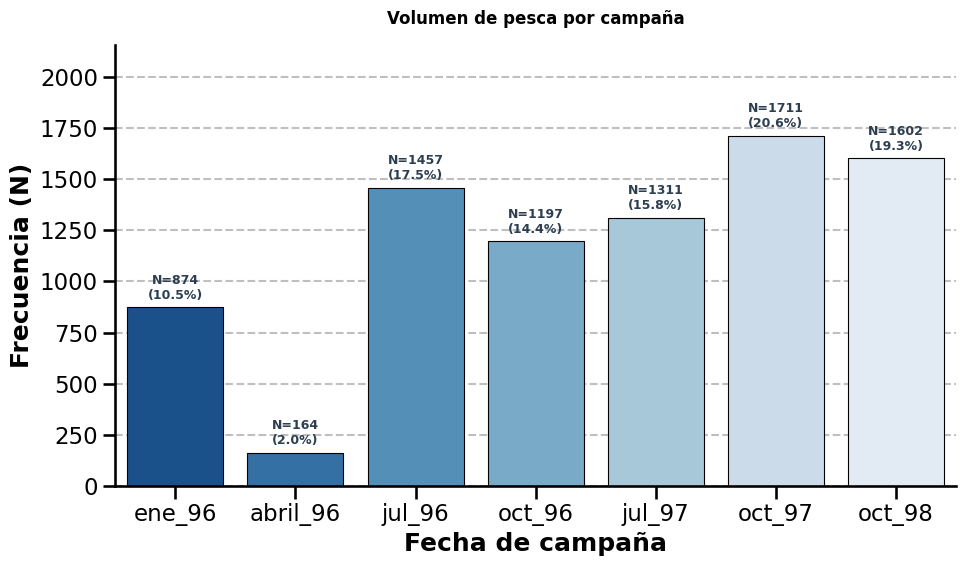

In [57]:
plt.figure(figsize=(10, 6))

# 1. Gráfico de conteo directo con la columna str original
ax = sns.countplot(
    data=df,
    x='fecha',
    hue='fecha',
    palette='Blues_r',
    legend=False,
    edgecolor='black',
    linewidth=0.8,
)

# 2. Total de registros no nulos para calcular el porcentaje
total = df['fecha'].notna().sum()

# 3. Anotar N y % sobre cada barra
for p in ax.patches:
    height = p.get_height()
    if height > 0:
        pct = 100 * height / total
        ax.annotate(
            f'N={int(height)}\n({pct:.1f}%)',
            (p.get_x() + p.get_width() / 2.0, height),
            ha='center',
            va='bottom',
            xytext=(0, 4),
            textcoords='offset points',
            fontsize=9,
            fontweight='bold',
            color='#2c3e50',
        )

# 4. Ajuste dinámico del margen superior para evitar corte de texto
plt.ylim(0, ax.get_ylim()[1] * 1.20)

# Estética
plt.title(
    'Volumen de pesca por campaña',
    fontsize=12,
    fontweight='bold',
    pad=15,
)
plt.xlabel('Fecha de campaña', fontweight='bold')
plt.ylabel('Frecuencia (N)', fontweight='bold')

sns.despine(top=True, right=True)
ax.set_axisbelow(True)
plt.grid(axis='y', linestyle='--', alpha=0.5, color='gray')
plt.tight_layout()
plt.show()

/tmp/ipykernel_3870/4174520475.py:35: FutureWarning:

The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.



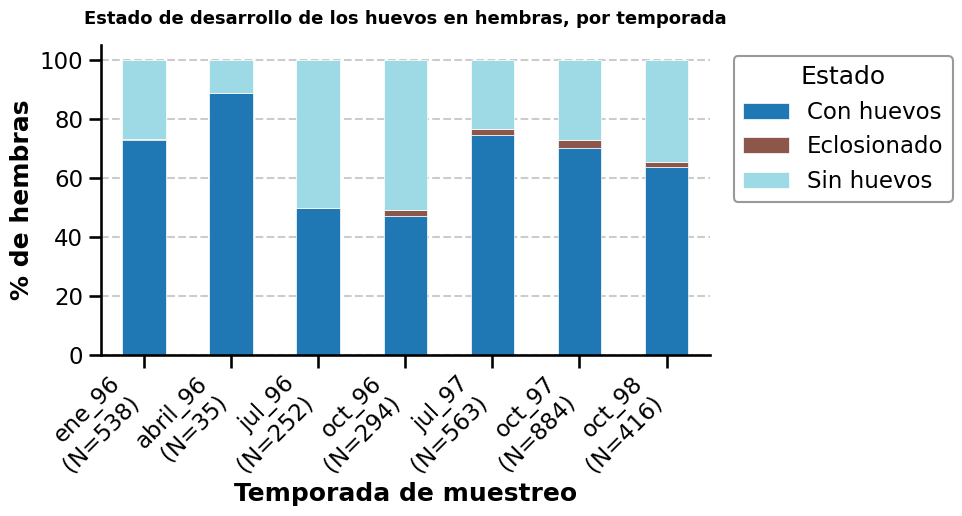

In [58]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns

huevos_map = {
    0: 'Sin huevos', 1: 'Con huevos', 2: 'Con huevos',
    3: 'Con huevos', 4: 'Eclosionado', 5: 'Sin huevos',
    6: 'Sin huevos', 7: 'Sin huevos'
}

df_plot = df.copy()

# Mapeo de sexo (1: Macho, 2: Hembra)
mapa_sexo = {1: 'Macho', 2: 'Hembra'}
df_plot['sexo_nom'] = df_plot['sexo'].map(mapa_sexo).fillna(df_plot['sexo'])

# Conversión y filtrado numérico de estado de huevos (0-7)
huevos_num = pd.to_numeric(df_plot['huevos'], errors='coerce')

# Filtrado exclusivo de hembras (sexo == 2 o 'Hembra') con registro de huevos válido
hembras = df_plot.loc[
    ((df_plot['sexo'] == 2) | (df_plot['sexo_nom'] == 'Hembra')) &
    huevos_num.between(0, 7)
].copy()

hembras['estado_huevos'] = huevos_num.loc[hembras.index].map(huevos_map)

# Orden cronológico de campañas
orden_temporada = ['ene_96', 'abril_96', 'jul_96', 'oct_96', 'jul_97', 'oct_97', 'oct_98']

# Tabla de frecuencias relativas (%) y tamaños muestrales
tab_huevos = pd.crosstab(hembras['fecha'], hembras['estado_huevos'], normalize='index') * 100
tab_huevos = tab_huevos.reindex(orden_temporada)
n_temporada = hembras.groupby('fecha').size().reindex(orden_temporada)

# Generación del gráfico
fig, ax = plt.subplots(figsize=(10, 5.5))
tab_huevos.plot(kind='bar', stacked=True, ax=ax, colormap='tab20', edgecolor='white', linewidth=0.5)

etiquetas_x = [f"{t}\n(N={int(n_temporada[t]) if pd.notna(n_temporada[t]) else 0})" for t in orden_temporada]
ax.set_xticklabels(etiquetas_x, rotation=45, ha='right')
ax.set_xlabel('Temporada de muestreo', fontweight='bold')
ax.set_ylabel('% de hembras', fontweight='bold')
ax.set_title('Estado de desarrollo de los huevos en hembras, por temporada', fontsize=13, fontweight='bold', pad=15)
ax.legend(title='Estado', bbox_to_anchor=(1.02, 1), loc='upper left', frameon=True, facecolor='white', edgecolor='gray')

sns.despine()
ax.set_axisbelow(True)
plt.grid(axis='y', linestyle='--', alpha=0.4, color='gray')
plt.tight_layout()
plt.show()